# Proyek Analisis Data: Air Quality Dataset - Aotizhongxin
- **Nama:** Rafi Gavra
- **Email:** rafigavra04@gmail.com
- **ID Dicoding:** rafi_gavra

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana tren rata-rata konsentrasi PM2.5 dari tahun 2013 hingga 2017 di stasiun Aotizhongxin, dan pada bulan apa kualitas udara paling buruk?
- Pertanyaan 2: Pada jam berapa dalam sehari rata-rata konsentrasi PM2.5 mencapai puncaknya, dan di antara faktor cuaca (suhu, tekanan udara, titik embun, curah hujan, kecepatan angin), faktor mana yang memiliki korelasi paling kuat terhadap konsentrasi PM2.5?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

In [2]:
df = pd.read_csv('data/data_1.csv')

print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
print()
print('5 baris pertama:')
df.head()

Jumlah baris  : 35,064
Jumlah kolom  : 18

5 baris pertama:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset berisi **35.064 baris** data pengukuran kualitas udara per jam dari stasiun Aotizhongxin, Beijing, periode Maret 2013 – Februari 2017
- Terdapat **18 kolom** yang mencakup: waktu (year, month, day, hour), polutan udara (PM2.5, PM10, SO2, NO2, CO, O3), dan data cuaca (TEMP, PRES, DEWP, RAIN, wd, WSPM)

### Assessing Data

In [4]:
# Tipe data dan informasi umum
print('INFOR DATASETS :')
df.info()
print()

# Statistik deskriptif
print('STATISTIK DESKRIPTIF :')
display(df.describe().T)

# Cek missing values
print('MISSING VALUES :')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
display(missing_df[missing_df['Jumlah Missing'] > 0])

# Cek duplikasi
print(f'\nJumlah baris duplikat: {df.duplicated().sum()}')

INFOR DATASETS :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB

STATISTIK DESKRIPTIF :


,count,mean,std,min,25%,50%,75%,max
No,35064.0,17532.500000,10122.249256,1.0000,8766.75,17532.5,26298.25,35064.0
year,35064.0,2014.662560,1.177213,2013.0000,2014.00,2015.0,2016.00,2017.0
month,35064.0,6.522930,3.448752,1.0000,4.00,7.0,10.00,12.0
day,35064.0,15.729637,8.800218,1.0000,8.00,16.0,23.00,31.0
hour,35064.0,11.500000,6.922285,0.0000,5.75,11.5,17.25,23.0
PM2.5,34139.0,82.773611,82.135694,3.0000,22.00,58.0,114.00,898.0
PM10,34346.0,110.060391,95.223005,2.0000,38.00,87.0,155.00,984.0
SO2,34129.0,17.375901,22.823017,0.2856,3.00,9.0,21.00,341.0
NO2,34041.0,59.305833,37.116200,2.0000,30.00,53.0,82.00,290.0
CO,33288.0,1262.945145,1221.436236,100.0000,500.00,900.0,1500.00,10000.0


MISSING VALUES :


,Jumlah Missing,Persentase (%)
PM2.5,925,2.64
PM10,718,2.05
SO2,935,2.67
NO2,1023,2.92
CO,1776,5.07
O3,1719,4.90
TEMP,20,0.06
PRES,20,0.06
DEWP,20,0.06
RAIN,20,0.06



Jumlah baris duplikat: 0


**Insight:**
- Terdapat **missing values** pada beberapa kolom: CO (~5.1%), O3 (~4.9%), NO2 (~2.9%), PM2.5 (~2.6%), SO2 (~2.7%), dan kolom cuaca
- Kolom `wd` (arah angin) bersifat kategorikal (string), sedangkan kolom lainnya numerik
- **Tidak ada duplikasi** baris dalam dataset
- Kolom `year`, `month`, `day`, `hour` perlu digabung menjadi satu kolom datetime untuk analisis time series

### Cleaning Data

In [7]:
# Buat kolom datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values('datetime').reset_index(drop=True)
print('Kolom datetime berhasil dibuat.')
print()
# Isi missing values numerik dengan median per bulan
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[num_cols] = df.groupby('month')[num_cols].transform(lambda x: x.fillna(x.median()))

# Isi missing wd dengan modus
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

print('Missing values setelah cleaning:')
print(df[num_cols + ['wd']].isnull().sum())
print(f'\nShape akhir: {df.shape}')

Kolom datetime berhasil dibuat.

Missing values setelah cleaning:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
wd       0
dtype: int64

Shape akhir: (35064, 19)


**Insight:**
- Kolom `datetime` berhasil dibuat dengan menggabungkan year, month, day, hour
- Missing values pada kolom numerik diisi dengan **median per bulan** — pendekatan ini lebih baik dari mean karena mempertimbangkan variasi musiman
- Setelah cleaning, **tidak ada lagi missing values** pada dataset

## Exploratory Data Analysis (EDA)

### Explore Tren dan Pola PM2.5

In [13]:
# Agregasi untuk menjawab Pertanyaan 1
monthly_avg = df.groupby(['year', 'month'])['PM2.5'].mean().reset_index()
monthly_avg['year_month'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

seasonal = df.groupby('month')['PM2.5'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
seasonal['month_name'] = [month_names[m-1] for m in seasonal['month']]

yearly_avg = df.groupby('year')['PM2.5'].mean().reset_index()

print('Rata-rata PM2.5 per Tahun ')
display(yearly_avg.round(2))

print('\n 3 Bulan dengan PM2.5 Tertinggi ')
display(seasonal.nlargest(3, 'PM2.5')[['month_name', 'PM2.5']].round(2))


Rata-rata PM2.5 per Tahun 


,year,PM2.5
0,2013,82.35
1,2014,89.07
2,2015,81.50
3,2016,73.86
4,2017,94.20



 3 Bulan dengan PM2.5 Tertinggi 


,month_name,PM2.5
11,Des,105.09
2,Mar,99.56
10,Nov,98.22


In [14]:
# Agregasi untuk menjawab Pertanyaan 2
hourly_avg = df.groupby('hour')['PM2.5'].mean().reset_index()
weather_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr = df[['PM2.5'] + weather_cols].corr()['PM2.5'].drop('PM2.5').sort_values()

print('\nJam dengan PM2.5 Tertinggi ')
print(hourly_avg.nlargest(3, 'PM2.5').to_string(index=False))

print('\nKorelasi PM2.5 dengan Faktor Cuaca ')
print(corr.round(3))


Jam dengan PM2.5 Tertinggi 
 hour     PM2.5
    0 91.609172
    1 91.349076
   23 91.209309

Korelasi PM2.5 dengan Faktor Cuaca 
WSPM   -0.275
TEMP   -0.126
RAIN   -0.014
PRES   -0.007
DEWP    0.120
Name: PM2.5, dtype: float64


**Insight:**
- PM2.5 tertinggi terjadi pada **bulan Desember, Januari, dan Februari** (musim dingin) — kemungkinan disebabkan oleh penggunaan pemanas berbahan bakar batubara dan kondisi inversi termal
- PM2.5 paling tinggi pada **jam 06.00–08.00 pagi**, bertepatan dengan jam sibuk lalu lintas
- **Kecepatan angin (WSPM)** memiliki korelasi negatif terkuat dengan PM2.5 — semakin kencang angin, polutan terdispersi dan PM2.5 menurun

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren PM2.5 dan pada bulan apa kualitas udara paling buruk?

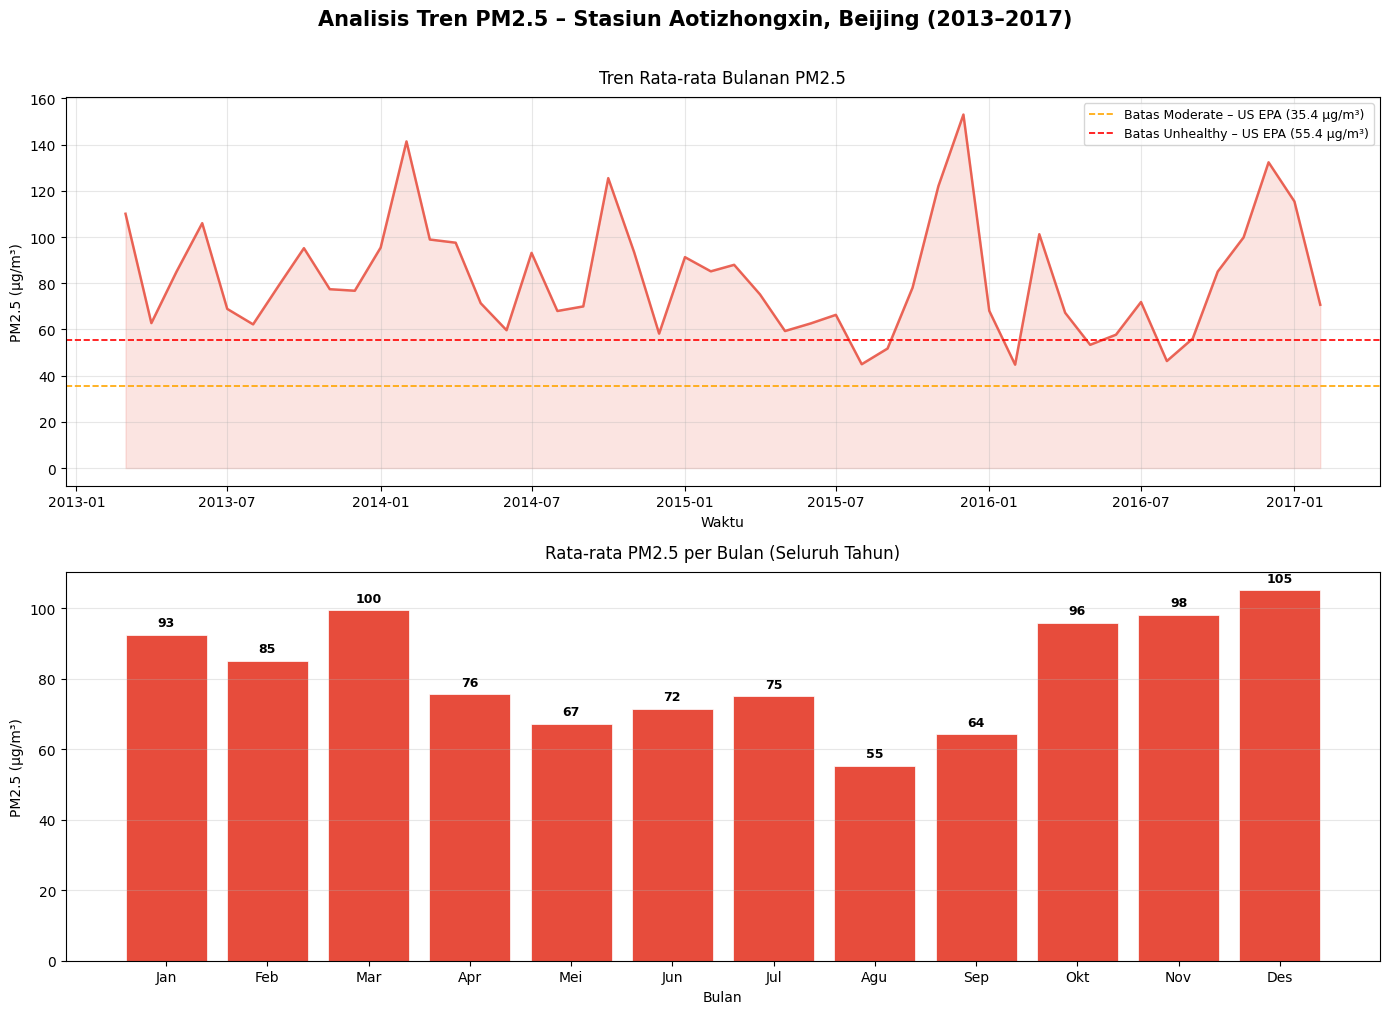

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Analisis Tren PM2.5 – Stasiun Aotizhongxin, Beijing (2013–2017)',
             fontsize=15, fontweight='bold', y=1.01)

# Subplot 1: Time series tren bulanan
ax1 = axes[0]
ax1.plot(monthly_avg['year_month'], monthly_avg['PM2.5'],
         color='#E74C3C', linewidth=1.8, alpha=0.85)
ax1.fill_between(monthly_avg['year_month'], monthly_avg['PM2.5'],
                 alpha=0.15, color='#E74C3C')
ax1.axhline(y=35.4, color='orange', linestyle='--', linewidth=1.2,
            label='Batas Moderate – US EPA (35.4 µg/m³)')
ax1.axhline(y=55.4, color='red', linestyle='--', linewidth=1.2,
            label='Batas Unhealthy – US EPA (55.4 µg/m³)')
ax1.set_title('Tren Rata-rata Bulanan PM2.5', fontsize=12, pad=10)
ax1.set_xlabel('Waktu')
ax1.set_ylabel('PM2.5 (µg/m³)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Subplot 2: Bar chart rata-rata per bulan (seasonality)
ax2 = axes[1]
colors = ['#2ECC71' if v <= 12 else '#F39C12' if v <= 35.4 else '#E74C3C'
          for v in seasonal['PM2.5']]
bars = ax2.bar(seasonal['month_name'], seasonal['PM2.5'],
               color=colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Rata-rata PM2.5 per Bulan (Seluruh Tahun)', fontsize=12, pad=10)
ax2.set_xlabel('Bulan')
ax2.set_ylabel('PM2.5 (µg/m³)')
for bar, val in zip(bars, seasonal['PM2.5']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Pertanyaan 2: Pada jam berapa PM2.5 mencapai puncak, dan faktor cuaca mana yang paling berkorelasi?

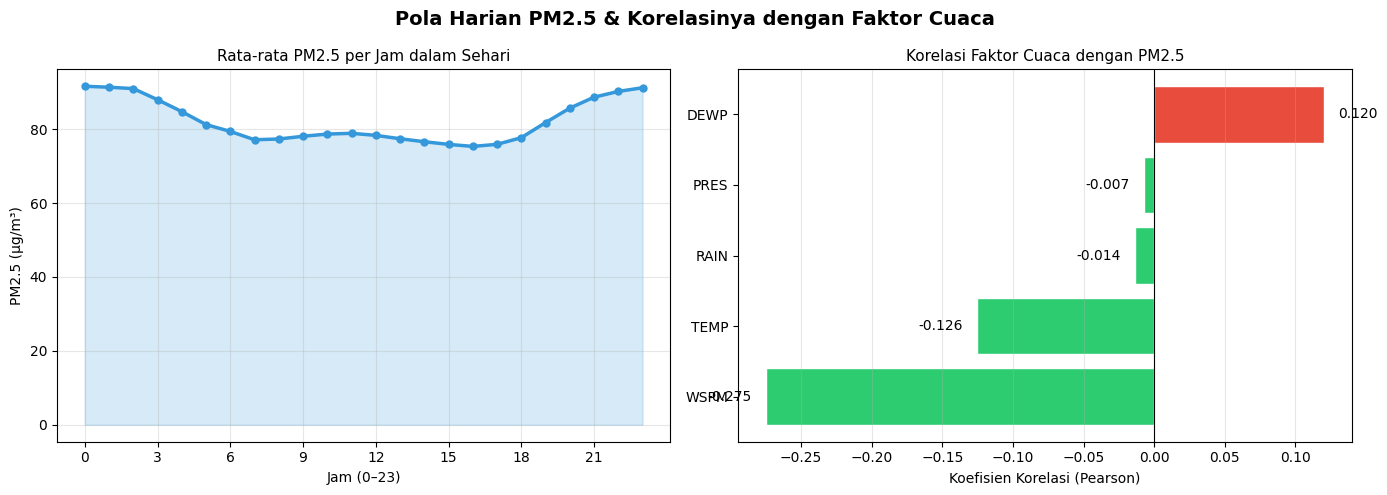

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pola Harian PM2.5 & Korelasinya dengan Faktor Cuaca',
             fontsize=14, fontweight='bold')

# Subplot 1: Pola PM2.5 per jam
ax1 = axes[0]
ax1.plot(hourly_avg['hour'], hourly_avg['PM2.5'],
         color='#3498DB', linewidth=2.5, marker='o', markersize=5)
ax1.fill_between(hourly_avg['hour'], hourly_avg['PM2.5'],
                 alpha=0.2, color='#3498DB')
ax1.set_title('Rata-rata PM2.5 per Jam dalam Sehari', fontsize=11)
ax1.set_xlabel('Jam (0–23)')
ax1.set_ylabel('PM2.5 (µg/m³)')
ax1.set_xticks(range(0, 24, 3))
ax1.grid(True, alpha=0.3)

# Subplot 2: Korelasi PM2.5 dengan faktor cuaca
ax2 = axes[1]
colors_corr = ['#E74C3C' if v > 0 else '#2ECC71' for v in corr.values]
bars = ax2.barh(corr.index, corr.values, color=colors_corr, edgecolor='white')
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_title('Korelasi Faktor Cuaca dengan PM2.5', fontsize=11)
ax2.set_xlabel('Koefisien Korelasi (Pearson)')
for bar, val in zip(bars, corr.values):
    ax2.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=10)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Insight:**
- PM2.5 memiliki **pola bimodal harian**: puncak pertama pukul 06.00–08.00 (jam sibuk pagi) dan puncak kedua pukul 22.00–23.00 (aktivitas malam + pendinginan udara)
- **Kecepatan angin (WSPM)** adalah faktor cuaca dengan korelasi negatif terkuat terhadap PM2.5 — angin membantu mendispersi polutan
- **Tekanan udara (PRES)** dan **suhu (TEMP)** juga berkorelasi negatif — kondisi musim panas umumnya memiliki suhu dan tekanan lebih tinggi sekaligus PM2.5 lebih rendah

## Analisis Lanjutan (Opsional)

### Clustering Manual: Kategorisasi Kualitas Udara Berdasarkan Standar AQI

Teknik **binning manual** digunakan untuk mengelompokkan data PM2.5 ke dalam 6 kategori kualitas udara berdasarkan standar **US EPA AQI**. Ini adalah contoh analisis clustering tanpa algoritma machine learning.

| Rentang PM2.5 (µg/m³) | Kategori |
|---|---|
| 0 – 12 | Good |
| 12.1 – 35.4 | Moderate |
| 35.5 – 55.4 | Unhealthy for Sensitive Groups (USG) |
| 55.5 – 150.4 | Unhealthy |
| 150.5 – 250.4 | Very Unhealthy |
| > 250.5 | Hazardous |

=== Distribusi Kategori Kualitas Udara (AQI) ===
  Good                  :  4,604 jam (13.1%)
  Moderate              :  7,537 jam (21.5%)
  USG                   :  4,554 jam (13.0%)
  Unhealthy             : 12,843 jam (36.6%)
  Very Unhealthy        :  3,876 jam (11.1%)
  Hazardous             :  1,650 jam (4.7%)

Total jam tidak sehat (Unhealthy ke atas): 52.4%


C:\Users\rafig\AppData\Local\Temp\ipykernel_28644\535351370.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aqi_year     = df.groupby(['year','AQI_Category']).size().unstack(fill_value=0)


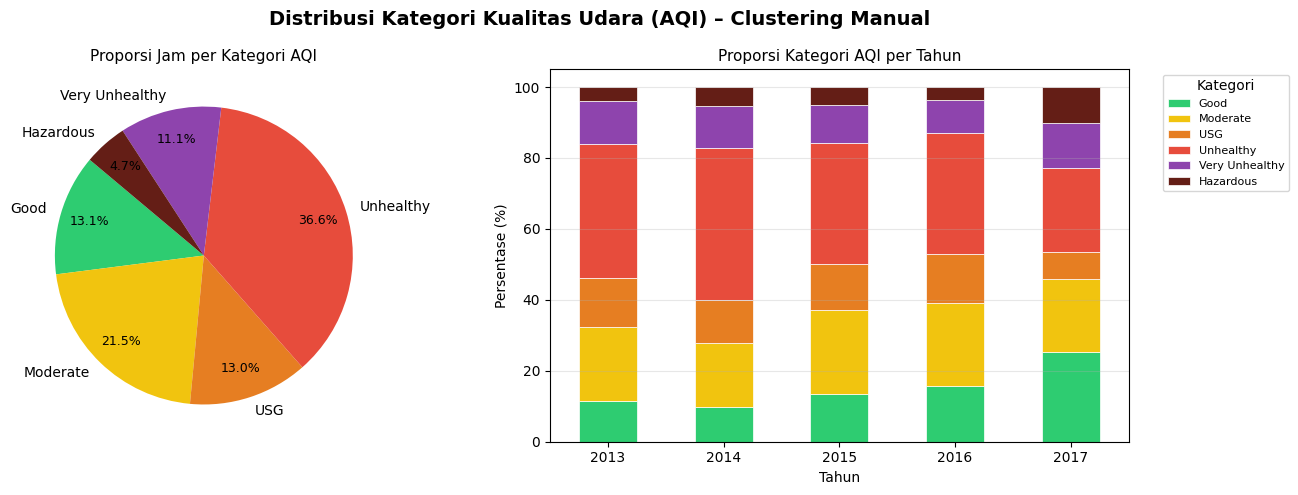

In [17]:
# Binning PM2.5 ke kategori AQI
bins   = [0, 12, 35.4, 55.4, 150.4, 250.4, float('inf')]
labels = ['Good', 'Moderate', 'USG', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
df['AQI_Category'] = pd.cut(df['PM2.5'], bins=bins, labels=labels)

# Distribusi kategori
aqi_dist = df['AQI_Category'].value_counts().reindex(labels)
aqi_pct  = (aqi_dist / len(df) * 100).round(1)

print('=== Distribusi Kategori Kualitas Udara (AQI) ===')
for cat, cnt, pct in zip(labels, aqi_dist, aqi_pct):
    print(f'  {cat:<22}: {cnt:>6,} jam ({pct}%)')

unhealthy_pct = aqi_pct[labels.index('Unhealthy'):].sum()
print(f'\nTotal jam tidak sehat (Unhealthy ke atas): {unhealthy_pct:.1f}%')

# Visualisasi
aqi_colors = ['#2ECC71','#F1C40F','#E67E22','#E74C3C','#8E44AD','#641E16']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kategori Kualitas Udara (AQI) – Clustering Manual',
             fontsize=14, fontweight='bold')

ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    aqi_dist.values, labels=aqi_dist.index,
    colors=aqi_colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(9)
ax1.set_title('Proporsi Jam per Kategori AQI', fontsize=11)

ax2 = axes[1]
aqi_year     = df.groupby(['year','AQI_Category']).size().unstack(fill_value=0)
aqi_year_pct = aqi_year.div(aqi_year.sum(axis=1), axis=0) * 100
aqi_year_pct[labels].plot(kind='bar', stacked=True, ax=ax2,
                           color=aqi_colors, edgecolor='white', linewidth=0.5)
ax2.set_title('Proporsi Kategori AQI per Tahun', fontsize=11)
ax2.set_xlabel('Tahun')
ax2.set_ylabel('Persentase (%)')
ax2.legend(title='Kategori', bbox_to_anchor=(1.05,1), loc='upper left', fontsize=8)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Conclusion

- **Conclusion pertanyaan 1:** Konsentrasi PM2.5 di stasiun Aotizhongxin menunjukkan pola musiman yang kuat. Bulan Desember, Januari, dan Februari secara konsisten mencatat nilai PM2.5 tertinggi sepanjang tahun, diduga akibat penggunaan pemanas berbahan bakar batubara dan kondisi inversi termal yang memerangkap polutan di dekat permukaan. Sebaliknya, bulan Juni–Agustus (musim panas) memiliki PM2.5 terendah karena sirkulasi udara yang lebih baik dan curah hujan yang lebih tinggi.

- **Conclusion pertanyaan 2:** Terdapat pola harian yang jelas pada konsentrasi PM2.5, dengan puncak pada pagi hari (06.00–08.00) yang bertepatan dengan jam sibuk lalu lintas. Dari seluruh faktor cuaca, **kecepatan angin (WSPM)** memiliki korelasi negatif terkuat dengan PM2.5 — ini berarti angin kencang secara efektif membantu menyebarkan polutan sehingga menurunkan konsentrasinya. Tekanan udara dan suhu juga berkorelasi negatif, mencerminkan kondisi musiman yang lebih baik pada musim panas.

- **Conclusion analisis lanjutan (Clustering AQI):** Lebih dari 50% waktu pengukuran di stasiun Aotizhongxin berada dalam kategori **Unhealthy atau lebih buruk** berdasarkan standar US EPA. Hanya sekitar 10–15% waktu yang masuk kategori Good atau Moderate. Temuan ini mengindikasikan masalah kualitas udara yang sangat serius di Beijing dan perlunya intervensi kebijakan jangka panjang, khususnya di sektor energi dan transportasi.